### Step 1: Load both CSVs correctly.

In [1]:
import pandas as pd

control = pd.read_csv('../data/raw/control_group.csv', delimiter=';')
test = pd.read_csv('../data/raw/test_group.csv', delimiter=';')

print(control.shape)
print(test.shape)
control.head()

(30, 10)
(30, 10)


,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Control Campaign,1.08.2019,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0
1,Control Campaign,2.08.2019,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0
2,Control Campaign,3.08.2019,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0
3,Control Campaign,4.08.2019,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0
4,Control Campaign,5.08.2019,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Step 2: Confirm the missing-data problem systematically

In [2]:
control.isnull().sum()

Campaign Name          0
Date                   0
Spend [USD]            0
# of Impressions       1
Reach                  1
# of Website Clicks    1
# of Searches          1
# of View Content      1
# of Add to Cart       1
# of Purchase          1
dtype: int64

In [3]:
test.isnull().sum()

Campaign Name          0
Date                   0
Spend [USD]            0
# of Impressions       0
Reach                  0
# of Website Clicks    0
# of Searches          0
# of View Content      0
# of Add to Cart       0
# of Purchase          0
dtype: int64

### Step 3: Decide how to handle that missing row

In [4]:
control_clean = control.dropna().reset_index(drop=True)
print(control_clean.shape)
control_clean.isnull().sum()

(29, 10)


Campaign Name          0
Date                   0
Spend [USD]            0
# of Impressions       0
Reach                  0
# of Website Clicks    0
# of Searches          0
# of View Content      0
# of Add to Cart       0
# of Purchase          0
dtype: int64

### Step 4: Rename the messy columns.

In [5]:
column_map = {
    'Campaign Name': 'campaign_name',
    'Date': 'date',
    'Spend [USD]': 'spend',
    '# of Impressions': 'impressions',
    'Reach': 'reach',
    '# of Website Clicks': 'clicks',
    '# of Searches': 'searches',
    '# of View Content': 'view_content',
    '# of Add to Cart': 'add_to_cart',
    '# of Purchase': 'purchases'
}

control_clean = control_clean.rename(columns=column_map)
test_clean = test.rename(columns=column_map)

control_clean.head()

,campaign_name,date,spend,impressions,reach,clicks,searches,view_content,add_to_cart,purchases
0,Control Campaign,1.08.2019,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0
1,Control Campaign,2.08.2019,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0
2,Control Campaign,3.08.2019,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0
3,Control Campaign,4.08.2019,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0
4,Control Campaign,6.08.2019,3083,109076.0,87998.0,4028.0,1709.0,1249.0,784.0,764.0


### Step 5: Fix the date column.

In [6]:
control_clean['date'] = pd.to_datetime(control_clean['date'], format='%d.%m.%Y')
test_clean['date'] = pd.to_datetime(test_clean['date'], format='%d.%m.%Y')

control_clean.dtypes

campaign_name            object
date             datetime64[ns]
spend                     int64
impressions             float64
reach                   float64
clicks                  float64
searches                float64
view_content            float64
add_to_cart             float64
purchases               float64
dtype: object

### Step 6: Convert those columns back to proper integers.

In [7]:
count_cols = ['impressions', 'reach', 'clicks', 'searches', 'view_content', 'add_to_cart', 'purchases']

control_clean[count_cols] = control_clean[count_cols].astype(int)
test_clean[count_cols] = test_clean[count_cols].astype(int)

control_clean.dtypes

campaign_name            object
date             datetime64[ns]
spend                     int64
impressions               int64
reach                     int64
clicks                    int64
searches                  int64
view_content              int64
add_to_cart               int64
purchases                 int64
dtype: object

### Step 7: Check for outliers before we merge.

In [8]:
control_clean.describe()

,date,spend,impressions,reach,clicks,searches,view_content,add_to_cart,purchases
count,29,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000
mean,2019-08-15 20:41:22.758620672,2304.068966,109559.758621,88844.931034,5320.793103,2221.310345,1943.793103,1300.000000,522.793103
min,2019-08-01 00:00:00,1757.000000,71274.000000,42859.000000,2277.000000,1001.000000,848.000000,442.000000,222.000000
25%,2019-08-09 00:00:00,1962.000000,92029.000000,74192.000000,4085.000000,1615.000000,1249.000000,930.000000,372.000000
50%,2019-08-16 00:00:00,2319.000000,113430.000000,91579.000000,5224.000000,2390.000000,1984.000000,1339.000000,501.000000
75%,2019-08-23 00:00:00,2544.000000,121332.000000,102479.000000,6628.000000,2711.000000,2421.000000,1641.000000,670.000000
max,2019-08-30 00:00:00,3083.000000,145248.000000,127852.000000,8137.000000,4891.000000,4219.000000,1913.000000,800.000000
std,NaN,363.534822,21688.922908,21832.349595,1757.369003,866.089368,777.545469,407.457973,185.028642


In [9]:
test_clean.describe()

,date,spend,impressions,reach,clicks,searches,view_content,add_to_cart,purchases
count,30,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,2019-08-15 12:00:00,2563.066667,74584.800000,53491.566667,6032.333333,2418.966667,1858.000000,881.533333,521.233333
min,2019-08-01 00:00:00,1968.000000,22521.000000,10598.000000,3038.000000,1854.000000,858.000000,278.000000,238.000000
25%,2019-08-08 06:00:00,2324.500000,47541.250000,31516.250000,4407.000000,2043.000000,1320.000000,582.500000,298.000000
50%,2019-08-15 12:00:00,2584.000000,68853.500000,44219.500000,6242.500000,2395.500000,1881.000000,974.000000,500.000000
75%,2019-08-22 18:00:00,2836.250000,99500.000000,78778.750000,7604.750000,2801.250000,2412.000000,1148.500000,701.000000
max,2019-08-30 00:00:00,3112.000000,133771.000000,109834.000000,8264.000000,2978.000000,2801.000000,1391.000000,890.000000
std,NaN,348.687681,32121.377422,28795.775752,1708.567263,388.742312,597.654669,347.584248,211.047745


### Step 8 (final cleaning step): merge control_clean and test_clean

In [10]:
combined = pd.concat([control_clean, test_clean], ignore_index=True)
combined.shape
combined['campaign_name'].value_counts()

campaign_name
Test Campaign       30
Control Campaign    29
Name: count, dtype: int64

### EDA

### Step 1: Aggregate comparison

In [11]:
summary = combined.groupby('campaign_name')[['spend', 'impressions', 'reach', 'clicks', 'searches', 'view_content', 'add_to_cart', 'purchases']].sum()
summary

,spend,impressions,reach,clicks,searches,view_content,add_to_cart,purchases
campaign_name,,,,,,,,
Control Campaign,66818,3177233,2576503,154303,64418,56370,37700,15161
Test Campaign,76892,2237544,1604747,180970,72569,55740,26446,15637


### Step 2: Normalize to daily averages, and calculate funnel conversion rates

In [12]:
summary['avg_daily_purchases'] = combined.groupby('campaign_name')['purchases'].mean()
summary['click_through_rate'] = summary['clicks'] / summary['impressions']
summary['cart_rate'] = summary['add_to_cart'] / summary['clicks']
summary['purchase_rate'] = summary['purchases'] / summary['add_to_cart']
summary['cost_per_purchase'] = summary['spend'] / summary['purchases']

summary[['avg_daily_purchases', 'click_through_rate', 'cart_rate', 'purchase_rate', 'cost_per_purchase']]

,avg_daily_purchases,click_through_rate,cart_rate,purchase_rate,cost_per_purchase
campaign_name,,,,,
Control Campaign,522.793103,0.048565,0.244324,0.402149,4.407229
Test Campaign,521.233333,0.080879,0.146135,0.591280,4.917312


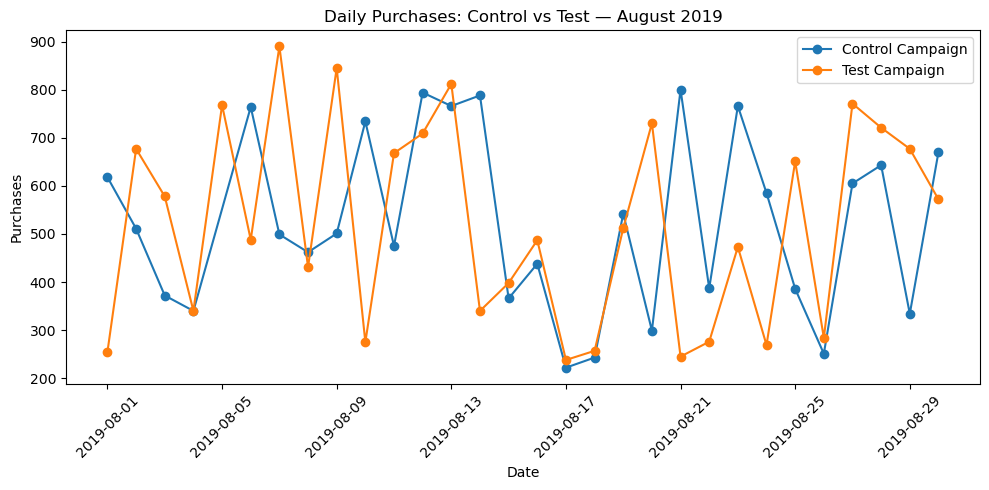

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,5))
for name, group in combined.groupby('campaign_name'):
    ax.plot(group['date'], group['purchases'], marker='o', label=name)

ax.set_title('Daily Purchases: Control vs Test — August 2019')
ax.set_xlabel('Date')
ax.set_ylabel('Purchases')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Statistics

### Step 1: Check normality with a quick visual.

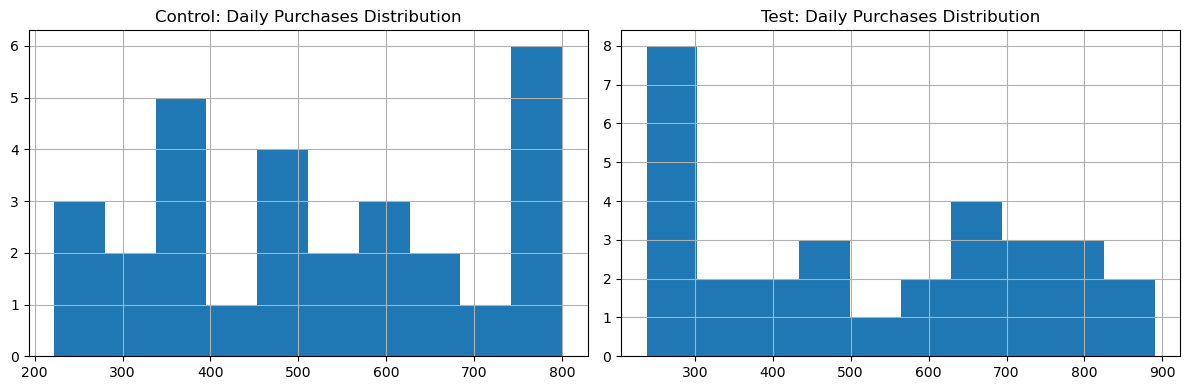

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

control_clean['purchases'].hist(ax=axes[0], bins=10)
axes[0].set_title('Control: Daily Purchases Distribution')

test_clean['purchases'].hist(ax=axes[1], bins=10)
axes[1].set_title('Test: Daily Purchases Distribution')

plt.tight_layout()
plt.show()

### Step 2: Formal normality test (Shapiro-Wilk).

In [15]:
from scipy import stats

control_shapiro = stats.shapiro(control_clean['purchases'])
test_shapiro = stats.shapiro(test_clean['purchases'])

print("Control Shapiro-Wilk:", control_shapiro)
print("Test Shapiro-Wilk:", test_shapiro)

Control Shapiro-Wilk: ShapiroResult(statistic=np.float64(0.938141969247496), pvalue=np.float64(0.08964421284477989))
Test Shapiro-Wilk: ShapiroResult(statistic=np.float64(0.9181893816994644), pvalue=np.float64(0.02407767129664654))


### Step 3: Run the Mann-Whitney U test.

In [16]:
u_stat, p_value = stats.mannwhitneyu(control_clean['purchases'], test_clean['purchases'], alternative='two-sided')

print("U statistic:", u_stat)
print("p-value:", p_value)

U statistic: 439.0
p-value: 0.957674926453464


### Step 4: Effect size + a quick power sanity check.

In [17]:
from numpy import mean, std
import math

def cohens_d(a, b):
    n1, n2 = len(a), len(b)
    pooled_std = math.sqrt(((n1-1)*std(a, ddof=1)**2 + (n2-1)*std(b, ddof=1)**2) / (n1+n2-2))
    return (mean(a) - mean(b)) / pooled_std

d = cohens_d(control_clean['purchases'], test_clean['purchases'])
print("Cohen's d (effect size):", d)

Cohen's d (effect size): 0.007850164648185842


In [18]:
combined.to_csv('../data/processed/campaigns_clean.csv', index=False)